<a href="https://colab.research.google.com/github/Abdulrehmanshabir/AQI-Data-Science-project/blob/main/AQI_RL_Traffic_Control_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving global_air_quality_dataset.csv to global_air_quality_dataset.csv


In [5]:
df = pd.read_csv("global_air_quality_dataset.csv")
df.head()

,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


In [6]:
print(df['AQI'].head())

0     38
1    280
2    117
3    197
4    187
Name: AQI, dtype: int64


Outputs reused from Assignment 3:
- Cleaned AQI Dataset
- AQI Values
- AQI Categories
- Data Cleaning Results
- Exploratory Data Analysis Results

**Part B**

| Component   | Definition                                             |
| ----------- | ------------------------------------------------------ |
| Agent       | Adaptive Traffic Control Decision Maker                |
| Environment | AQI Dataset                                            |
| State       | Low AQI, Medium AQI, High AQI                          |
| Action      | No Restriction, Partial Restriction, High Alert        |
| Reward      | Positive for correct action, negative for wrong action |
| Policy      | Best action for each AQI state                         |
| Episode     | One complete training cycle                            |


**Part C: AQI State Creation**

In [7]:
def get_state(aqi):

    if aqi <= 100:
        return 0

    elif aqi <= 200:
        return 1

    else:
        return 2

In [9]:
df['State'] = df['AQI'].apply(get_state)

In [10]:
df[['AQI','State']].head()

,AQI,State
0,38,0
1,280,2
2,117,1
3,197,1
4,187,1


In [11]:
df['State'].value_counts()

,count
State,
2,1360
1,1330
0,970


**Part D: Action Space**

| Action ID | Action               |
| --------- | -------------------- |
| 0         | No Restriction       |
| 1         | Partial Restriction  |
| 2         | High Pollution Alert |


**Part E: Reward System**

In [12]:
reward_table = {

    0:[10,-2,-5],

    1:[-6,10,2],

    2:[-10,-3,10]

}

In [13]:
reward_table

{0: [10, -2, -5], 1: [-6, 10, 2], 2: [-10, -3, 10]}

**Part F: Q-Learning Implementation**

In [14]:
states = 3
actions = 3

Q = np.zeros((states, actions))

In [15]:
alpha = 0.1
gamma = 0.9
epsilon = 0.2

episodes = 500

In [16]:
states_data = df['State'].values

In [17]:
episode_rewards = []

for episode in range(episodes):

    total_reward = 0

    for state in states_data:

        if np.random.rand() < epsilon:

            action = np.random.randint(actions)

        else:

            action = np.argmax(Q[state])

        reward = reward_table[state][action]

        next_state = state

        Q[state, action] = Q[state, action] + alpha * (

            reward +

            gamma * np.max(Q[next_state])

            - Q[state, action]

        )

        total_reward += reward

    episode_rewards.append(total_reward)

In [18]:
print(Q)

[[100.  88.  85.]
 [ 84. 100.  92.]
 [ 80.  87. 100.]]


In [19]:
policy = np.argmax(Q, axis=1)

print(policy)

[0 1 2]


**Part G: Simulation and Evaluation**

In [20]:
average_reward = np.mean(episode_rewards)

print("Average Reward:", average_reward)

Average Reward: 29750.456


In [21]:
action_names = {
    0:"No Restriction",
    1:"Partial Restriction",
    2:"High Pollution Alert"
}

for state in range(3):

    print(
        "State:",
        state,
        "->",
        action_names[policy[state]]
    )

State: 0 -> No Restriction
State: 1 -> Partial Restriction
State: 2 -> High Pollution Alert


In [22]:
comparison = pd.DataFrame({

    "AQI State":[
        "Low AQI",
        "Medium AQI",
        "High AQI"
    ],

    "Expected Action":[
        "No Restriction",
        "Partial Restriction",
        "High Pollution Alert"
    ],

    "Learned Action":[
        action_names[policy[0]],
        action_names[policy[1]],
        action_names[policy[2]]
    ]
})

comparison

,AQI State,Expected Action,Learned Action
0,Low AQI,No Restriction,No Restriction
1,Medium AQI,Partial Restriction,Partial Restriction
2,High AQI,High Pollution Alert,High Pollution Alert


In [23]:
comparison["Correct?"] = [

    comparison.loc[0,"Expected Action"] == comparison.loc[0,"Learned Action"],

    comparison.loc[1,"Expected Action"] == comparison.loc[1,"Learned Action"],

    comparison.loc[2,"Expected Action"] == comparison.loc[2,"Learned Action"]

]

comparison

,AQI State,Expected Action,Learned Action,Correct?
0,Low AQI,No Restriction,No Restriction,True
1,Medium AQI,Partial Restriction,Partial Restriction,True
2,High AQI,High Pollution Alert,High Pollution Alert,True


**Part H: Required Visualizations**

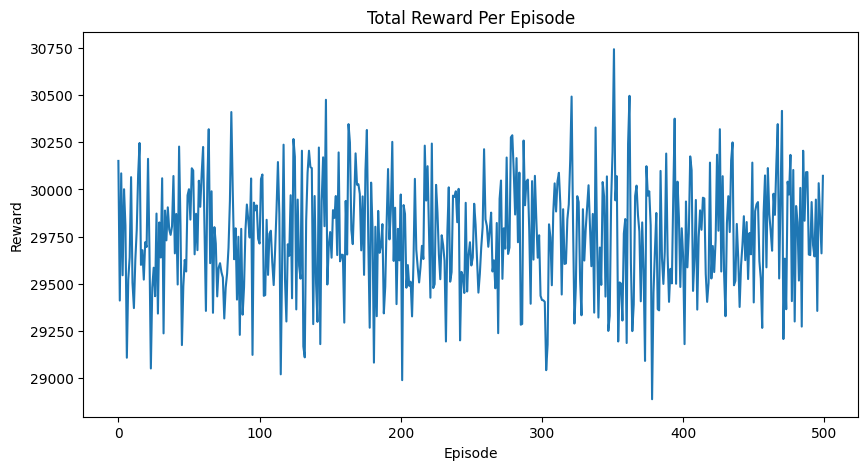

In [24]:
plt.figure(figsize=(10,5))

plt.plot(episode_rewards)

plt.title("Total Reward Per Episode")

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.show()

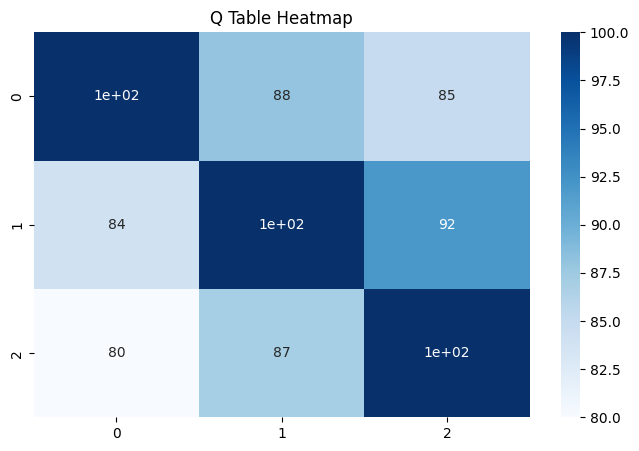

In [25]:
plt.figure(figsize=(8,5))

sns.heatmap(
    Q,
    annot=True,
    cmap="Blues"
)

plt.title("Q Table Heatmap")

plt.show()

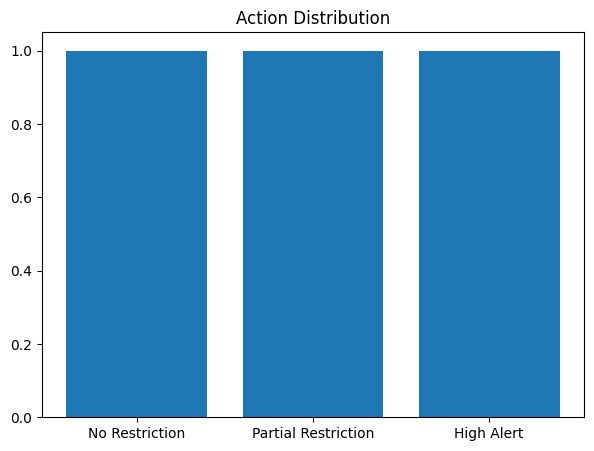

In [26]:
best_actions = np.argmax(Q, axis=1)

counts = np.bincount(
    best_actions,
    minlength=3
)

plt.figure(figsize=(7,5))

plt.bar(
    [
        "No Restriction",
        "Partial Restriction",
        "High Alert"
    ],
    counts
)

plt.title("Action Distribution")

plt.show()